# Tiền xử lý dữ liệu văn bản


## Bước này tạo files:

- df_meta.preprocessed.parquet

In [43]:
import re
import os
import torch
import numpy as np
import pandas as pd

In [4]:
PATH = "./data/2023"

## Text Feature Extraction


In [20]:
df_meta = pd.read_parquet(os.path.join(PATH, "df_meta.parquet"))

# df_meta = pd.read_json(os.path.join(PATH, "df_meta.jsonl"), lines=True)

In [21]:
df_meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 35997 entries, 0 to 35996
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    35236 non-null  str    
 1   title            35997 non-null  str    
 2   average_rating   35997 non-null  float64
 3   rating_number    35997 non-null  int64  
 4   features         35997 non-null  object 
 5   description      35997 non-null  object 
 6   price            17404 non-null  float64
 7   images           35997 non-null  object 
 8   videos           35997 non-null  object 
 9   store            35849 non-null  str    
 10  categories       35997 non-null  object 
 11  details          35997 non-null  object 
 12  asin             35997 non-null  str    
 13  bought_together  0 non-null      float64
 14  subtitle         0 non-null      float64
 15  author           0 non-null      object 
dtypes: float64(4), int64(1), object(7), str(4)
memory usage: 9.1+ MB


In [22]:
df_meta.head(3)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,asin,bought_together,subtitle,author
0,Baby,"Chicco Viaro Travel System, Teak",4.6,125,"[Aluminum, Imported, Convenient one-hand quick...","[Product Description, For ultimate convenience...",NaN,[{'hi_res': 'https://m.media-amazon.com/images...,"[{'title': 'Viaro Demo Video', 'url': 'https:/...",Chicco,"[Baby Products, Strollers & Accessories, Strol...","{'': None, 'ABPA Partslink Number': None, 'AC ...",B01C4319LO,NaN,NaN,None
1,Baby,Nuby iMonster Toddler Bowl,4.4,52,[Makes feeding fun for baby and easier for par...,[When babies begin to show interest in feeding...,NaN,[{'hi_res': 'https://m.media-amazon.com/images...,[],Nuby,"[Baby Products, Feeding, Solid Feeding, Dishes]","{'': None, 'ABPA Partslink Number': None, 'AC ...",B0083SXABC,NaN,NaN,None
2,Baby,XMWEALTHY Unisex Infant Swaddle Blankets Soft ...,4.7,5919,"[Outside 100% Acrylic, Inside 100%polyester, 👶...",[],28.99,[{'hi_res': 'https://m.media-amazon.com/images...,[{'title': 'Perfect Winter time Baby Burrito. ...,XMWEALTHY,"[Baby Products, Nursery, Bedding, Blankets & S...","{'': None, 'ABPA Partslink Number': None, 'AC ...",B07JM4RK9T,NaN,NaN,None


In [23]:
df_inter = pd.read_parquet(os.path.join(PATH, "df_inter.label.parquet"))

In [24]:
df_inter.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240219 entries, 0 to 1240218
Data columns (total 7 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   userID      1240219 non-null  int64
 1   itemID      1240219 non-null  int64
 2   rating      1240219 non-null  int64
 3   timestamp   1240219 non-null  int64
 4   reviewerID  1240219 non-null  str  
 5   asin        1240219 non-null  str  
 6   x_label     1240219 non-null  int64
dtypes: int64(5), str(2)
memory usage: 111.2 MB


In [29]:
df_inter.head(3)

,userID,itemID,rating,timestamp,reviewerID,asin,x_label
0,0,4,4,1655859477958,AEO4M665ZOCBF7HEFRMTUDHLSB5Q,B004JU0H6O,0
1,0,3,5,1655860079499,AEO4M665ZOCBF7HEFRMTUDHLSB5Q,B082WJTFRR,0
2,0,2,4,1655860597696,AEO4M665ZOCBF7HEFRMTUDHLSB5Q,B08FZJ3YHH,0


In [26]:
df_item_map = df_inter[["itemID", "asin"]].drop_duplicates()

In [27]:
df = pd.merge(df_item_map, df_meta, on="asin", how="inner")

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35997 entries, 0 to 35996
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   itemID           35997 non-null  int64  
 1   asin             35997 non-null  str    
 2   main_category    35236 non-null  str    
 3   title            35997 non-null  str    
 4   average_rating   35997 non-null  float64
 5   rating_number    35997 non-null  int64  
 6   features         35997 non-null  object 
 7   description      35997 non-null  object 
 8   price            17404 non-null  float64
 9   images           35997 non-null  object 
 10  videos           35997 non-null  object 
 11  store            35849 non-null  str    
 12  categories       35997 non-null  object 
 13  details          35997 non-null  object 
 14  bought_together  0 non-null      float64
 15  subtitle         0 non-null      float64
 16  author           0 non-null      object 
dtypes: float64(4), int64(2)

In [31]:
# df[df["salesRank"].isna() == False]["salesRank"]

In [32]:
# df.head(3)

In [33]:
df.sort_values(by=["itemID"], inplace=True)

print(f"shape: {df.shape}")

df[:3]

shape: (35997, 17)


,itemID,asin,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,bought_together,subtitle,author
4,0,B086QM7FVT,Baby,"Skip Hop Toddler Step Stool, Double Up",4.6,2482,"[A big-kid boost to toddler independence, our ...","[A big-kid boost to toddler independence, our ...",21.99,[{'hi_res': 'https://m.media-amazon.com/images...,"[{'title': 'My favorite step stool', 'url': 'h...",Skip Hop,"[Baby Products, Nursery, Furniture, Storage & ...","{'': None, 'ABPA Partslink Number': None, 'AC ...",NaN,NaN,None
3,1,B017IQZ9OK,Baby,"Boon Spring Countertop Drying Rack, Green (B11...",4.8,3885,[Drying rack: countertop drying rack holds ite...,[Boon Sprig countertop drying rack easily hold...,12.99,[{'hi_res': 'https://m.media-amazon.com/images...,[{'title': 'Versatile and space saving UPDATE ...,Boon,"[Baby Products, Feeding, Bottle-Feeding, Bottl...","{'': None, 'ABPA Partslink Number': None, 'AC ...",NaN,NaN,None
2,2,B08FZJ3YHH,Baby,Toilet Seat Covers Disposable - 20 Pack - Wate...,4.8,7996,[✔️ NO MORE STRESS when you need to use a publ...,[],15.97,[{'hi_res': 'https://m.media-amazon.com/images...,[{'title': 'Toilet Seat Covers Disposable: Fun...,Relyo,"[Baby Products, Potty Training, Seat Covers]","{'': None, 'ABPA Partslink Number': None, 'AC ...",NaN,NaN,None


In [35]:
# sentences: title + brand + category + description | All have title + description

title_na_df = df[df["title"].isnull()]
print(f"Title null count: {title_na_df.shape[0]}")

desc_na_df = df[df["description"].isnull()]
print(f"Description null count: {desc_na_df.shape[0]}")

na_df = df[df["description"].isnull() & df["title"].isnull()]
print(f"Title and description null count: {na_df.shape[0]}")

# na3_df = df[df["description"].isnull() & df["title"].isnull() & df["brand"].isnull()]
# print(f"Title, description, and brand null count: {na3_df.shape[0]}")

na4_df = df[
    df["description"].isnull()
    & df["title"].isnull()
    # & df["brand"].isnull()
    & df["categories"].isnull()
]
print(f"Title, description, brand, and categories null count: {na4_df.shape[0]}")

Title null count: 0
Description null count: 0
Title and description null count: 0
Title, description, brand, and categories null count: 0


In [36]:
_df = df.copy()

In [37]:
df = _df.copy()

In [38]:
df.head(3)

,itemID,asin,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,bought_together,subtitle,author
4,0,B086QM7FVT,Baby,"Skip Hop Toddler Step Stool, Double Up",4.6,2482,"[A big-kid boost to toddler independence, our ...","[A big-kid boost to toddler independence, our ...",21.99,[{'hi_res': 'https://m.media-amazon.com/images...,"[{'title': 'My favorite step stool', 'url': 'h...",Skip Hop,"[Baby Products, Nursery, Furniture, Storage & ...","{'': None, 'ABPA Partslink Number': None, 'AC ...",NaN,NaN,None
3,1,B017IQZ9OK,Baby,"Boon Spring Countertop Drying Rack, Green (B11...",4.8,3885,[Drying rack: countertop drying rack holds ite...,[Boon Sprig countertop drying rack easily hold...,12.99,[{'hi_res': 'https://m.media-amazon.com/images...,[{'title': 'Versatile and space saving UPDATE ...,Boon,"[Baby Products, Feeding, Bottle-Feeding, Bottl...","{'': None, 'ABPA Partslink Number': None, 'AC ...",NaN,NaN,None
2,2,B08FZJ3YHH,Baby,Toilet Seat Covers Disposable - 20 Pack - Wate...,4.8,7996,[✔️ NO MORE STRESS when you need to use a publ...,[],15.97,[{'hi_res': 'https://m.media-amazon.com/images...,[{'title': 'Toilet Seat Covers Disposable: Fun...,Relyo,"[Baby Products, Potty Training, Seat Covers]","{'': None, 'ABPA Partslink Number': None, 'AC ...",NaN,NaN,None


In [39]:
# Kiểm tra kiểu dữ liệu của phần tử đầu tiên
print(type(df["categories"].iloc[0]))

# Kiểm tra nội dung chi tiết
print(df["categories"].iloc[0])

<class 'numpy.ndarray'>
['Baby Products' 'Nursery' 'Furniture' 'Storage & Organization'
 'Step Stools']


In [40]:
df["main_category"]

4                            Baby
3                            Baby
2                            Baby
1                            Baby
0                            Baby
                   ...           
35992                        Baby
35993                 Amazon Home
35994    Tools & Home Improvement
35995                        Baby
35996    Tools & Home Improvement
Name: main_category, Length: 35997, dtype: str

In [20]:
df["categories"]

2       [[Baby]]
59      [[Baby]]
561     [[Baby]]
666     [[Baby]]
298     [[Baby]]
          ...   
5558    [[Baby]]
3410    [[Baby]]
5065    [[Baby]]
4699    [[Baby]]
490     [[Baby]]
Name: categories, Length: 7050, dtype: object

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 7050 entries, 2 to 490
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   itemID       7050 non-null   int64  
 1   asin         7050 non-null   str    
 2   categories   7050 non-null   object 
 3   description  6956 non-null   str    
 4   title        7037 non-null   str    
 5   price        6883 non-null   float64
 6   imUrl        7037 non-null   str    
 7   brand        4926 non-null   str    
 8   related      6946 non-null   object 
 9   salesRank    4 non-null      object 
dtypes: float64(1), int64(1), object(3), str(5)
memory usage: 5.0+ MB


In [174]:
def get_price_tag(price):
    try:
        price = float(price)
        if price <= 0:
            return ""
        if price < 15:
            return "budget"
        if price < 50:
            return "midrange"
        return "premium"
    except:
        return ""  # Trường hợp NaN hoặc không phải số

In [ ]:
# Áp dụng thử
df["price_tag"] = df["price"].apply(get_price_tag)

In [154]:
df["price_tag"].value_counts()

price_tag
low price budget friendly    2907
mid-range price              2571
high price luxury premium    1547
Name: count, dtype: int64

#### 2014

In [ ]:
# 1. Điền giá trị trống cho các cột text để tránh lỗi cộng chuỗi
text_cols = ["title", "brand", "description"]
for col in text_cols:
    df[col] = df[col].fillna("")


# 2. Hàm xử lý cái mảng Categories lồng nhằng của bạn
def clean_cats(cat_val):
    if isinstance(cat_val, list) and len(cat_val) > 0:
        # Gỡ lỗi [array(['Baby'])]
        return " ".join(list(cat_val[0]))
    return ""


# 3. Tổng hợp tất cả vào một cột duy nhất
df["combined_text"] = (
    df["title"]
    + " "
    + df["brand"]
    + " "
    + df["categories"].apply(clean_cats)
    + " "
    # + df["price"].apply(get_price_tag)
    # + " "
    + df["description"]
)

# 4. Làm sạch: bỏ xuống dòng, bỏ khoảng trắng thừa
df["combined_text"] = (
    df["combined_text"]
    .str.replace(r"\n", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

#### 2023

In [41]:
# 1. Điền giá trị trống cho các cột text và xử lý thay đổi tên cột (store thay cho brand)
# Lưu ý: Trong schema của bạn là 'store' chứ không phải 'brand'
text_cols = ["title", "store", "main_category"]
for col in text_cols:
    df[col] = df[col].fillna("").astype(str)

# 2. Hàm xử lý mảng (List/Array) cực mạnh cho Categories và Features
def flatten_list(val):
    if isinstance(val, (list, np.ndarray)):
        # Loại bỏ các giá trị None/NaN trong list và nối lại thành chuỗi
        clean_elements = [str(x) for x in val if pd.notnull(x)]
        return " ".join(clean_elements)
    return ""

# 3. Tổng hợp tất cả vào một cột duy nhất 'combined_text'
# Thứ tự ưu tiên: Title -> Store -> Category -> Features -> Description
print("🚀 Đang gom nhóm các trường văn bản...")

df["combined_text"] = (
    df["title"] + " " + 
    df["store"] + " " + 
    df["main_category"] + " " +
    df["categories"].apply(flatten_list) + " " +
    df["features"].apply(flatten_list) + " " +
    df["description"].apply(flatten_list)
)

# 4. Làm sạch triệt để: Bỏ HTML, xuống dòng, khoảng trắng thừa
# Dữ liệu Amazon 2023 thường có thẻ <br> trong description
df["combined_text"] = (
    df["combined_text"]
    .str.replace(r"<[^>]*>", " ", regex=True) # Xóa thẻ HTML
    .str.replace(r"\n|\r|\t", " ", regex=True) # Xóa xuống dòng, tab
    .str.replace(r"\s+", " ", regex=True)     # Gom nhiều khoảng trắng thành 1
    .str.strip()
)

# 5. Kiểm tra kết quả
print(f"✅ Đã tạo xong combined_text. Độ dài trung bình: {df['combined_text'].str.len().mean():.0f} ký tự.")

🚀 Đang gom nhóm các trường văn bản...
✅ Đã tạo xong combined_text. Độ dài trung bình: 1363 ký tự.


In [44]:
# Định nghĩa pattern tìm thẻ HTML: <...>, </...> hoặc &...;
html_pattern = r"<[^>]+>|&[a-z0-9]+;"

# Tạo mặt nạ (mask) để lọc các dòng có chứa HTML
has_html = df["combined_text"].str.contains(html_pattern, regex=True, na=False)

print(f"Số dòng chứa mã HTML: {has_html.sum()}")

# Xem thử 5 dòng đầu tiên dính mã HTML để đối chiếu
if has_html.sum() > 0:
    print("\nVí dụ các dòng dính mã HTML:")
    print(df[has_html]["combined_text"].head())

Số dòng chứa mã HTML: 26

Ví dụ các dòng dính mã HTML:
1208    Maxi-Cosi Adorra Modular 5-in-1 Travel System ...
1200    Ubbi 3-in-1 Potty with Built-in Splash Guard a...
3921    Storkcraft Portofino Convertible Crib And Chan...
5611    Boudreauxs Maximum Strength Butt Paste - 4 Oz ...
6984    White Anti-Tip Strap,Furniture Safety Straps,F...
Name: combined_text, dtype: str


In [45]:
import html

def clean_text_final(text):
    if not isinstance(text, str):
        return ""

    # 1. Giải mã HTML Entities (&reg; -> ®, &quot; -> ", v.v.)
    # Bước này cực kỳ quan trọng cho các ví dụ bạn vừa nêu
    text = html.unescape(text)

    # 2. Xóa các thẻ HTML thực thụ nếu có (ví dụ <br>, <div>)
    text = re.sub(r"<[^>]+>", " ", text)

    # 3. Thay thế các ký tự đặc biệt còn sót lại thành khoảng trắng (tùy chọn)
    # Nếu bạn muốn model tập trung vào chữ cái và số
    # text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # 4. Nén khoảng trắng thừa sau khi đã thay thế các mã HTML
    text = re.sub(r"\s+", " ", text).strip()

    # 5. Đảm bảo dấu '&' có khoảng trắng hai bên để model SBERT đọc dễ hơn
    text = re.sub(r"&", " & ", text)

    return text


# Áp dụng cho cột dữ liệu của bạn
df["combined_text"] = df["combined_text"].apply(clean_text_final)

# Kiểm tra lại số dòng chứa mã HTML (Sẽ về 0)
html_pattern = r"<[^>]+>|&[a-z0-9]+;"
remaining = df["combined_text"].str.contains(html_pattern, regex=True, na=False).sum()
print(f"Số dòng chứa mã HTML còn lại: {remaining}")

Số dòng chứa mã HTML còn lại: 0


In [46]:
df["sentences"] = df["combined_text"].tolist()

# Xem thử kết quả của 2 sản phẩm đầu tiên
for s in df["sentences"][:2]:
    print(f"--- \n {s} \n")

--- 
 Skip Hop Toddler Step Stool, Double Up Skip Hop Baby Baby Products Nursery Furniture Storage  &  Organization Step Stools A big-kid boost to toddler independence, our 2-in-1 step stool makes everything easier for kids to reach. Perfect at the bathroom sink and toilet for potty training, it’s also great as a kitchen helper and more Use the space-saving nesting stools together as a stepped design for an easier climb, or separately Interlocking design keeps stools securely attached when used together Featuring: Wide standing platforms, Non-slip bases  &  treads, Space-saving nesting design Size (inches): Large step stool: 13.25W x 8.5H x 10.25D; Small step stool: 10.375W x 6H x 10.25D A big-kid boost to toddler independence, our 2-in-1 step stool makes everything easier for kids to reach. Perfect at the bathroom sink and toilet for potty training, it’s also great as a kitchen helper and more. Use the space-saving nesting stools together as a stepped design for an easier climb, or se

In [47]:
df[:4]

,itemID,asin,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,bought_together,subtitle,author,combined_text,sentences
4,0,B086QM7FVT,Baby,"Skip Hop Toddler Step Stool, Double Up",4.6,2482,"[A big-kid boost to toddler independence, our ...","[A big-kid boost to toddler independence, our ...",21.99,[{'hi_res': 'https://m.media-amazon.com/images...,"[{'title': 'My favorite step stool', 'url': 'h...",Skip Hop,"[Baby Products, Nursery, Furniture, Storage & ...","{'': None, 'ABPA Partslink Number': None, 'AC ...",NaN,NaN,None,"Skip Hop Toddler Step Stool, Double Up Skip Ho...","Skip Hop Toddler Step Stool, Double Up Skip Ho..."
3,1,B017IQZ9OK,Baby,"Boon Spring Countertop Drying Rack, Green (B11...",4.8,3885,[Drying rack: countertop drying rack holds ite...,[Boon Sprig countertop drying rack easily hold...,12.99,[{'hi_res': 'https://m.media-amazon.com/images...,[{'title': 'Versatile and space saving UPDATE ...,Boon,"[Baby Products, Feeding, Bottle-Feeding, Bottl...","{'': None, 'ABPA Partslink Number': None, 'AC ...",NaN,NaN,None,"Boon Spring Countertop Drying Rack, Green (B11...","Boon Spring Countertop Drying Rack, Green (B11..."
2,2,B08FZJ3YHH,Baby,Toilet Seat Covers Disposable - 20 Pack - Wate...,4.8,7996,[✔️ NO MORE STRESS when you need to use a publ...,[],15.97,[{'hi_res': 'https://m.media-amazon.com/images...,[{'title': 'Toilet Seat Covers Disposable: Fun...,Relyo,"[Baby Products, Potty Training, Seat Covers]","{'': None, 'ABPA Partslink Number': None, 'AC ...",NaN,NaN,None,Toilet Seat Covers Disposable - 20 Pack - Wate...,Toilet Seat Covers Disposable - 20 Pack - Wate...
1,3,B082WJTFRR,Baby,hiccapop Inflatable Toddler Travel Bed with Sa...,4.8,11434,"[Perfect Anytime - Anywhere Toddler Bed, HOME,...",[],84.92,[{'hi_res': 'https://m.media-amazon.com/images...,[{'title': 'My 3 Year Review: Good Customer Se...,hiccapop,"[Baby Products, Travel Gear, Travel Beds, Infa...","{'': None, 'ABPA Partslink Number': None, 'AC ...",NaN,NaN,None,hiccapop Inflatable Toddler Travel Bed with Sa...,hiccapop Inflatable Toddler Travel Bed with Sa...


In [48]:
course_list = df["itemID"].tolist()
# sentences = df[desc_str].tolist()

assert course_list[-1] == len(course_list) - 1

In [ ]:
df.to_parquet(os.path.join(PATH, "df_meta.preprocessed.parquet"), index=False)

## Phân tích dữ liệu


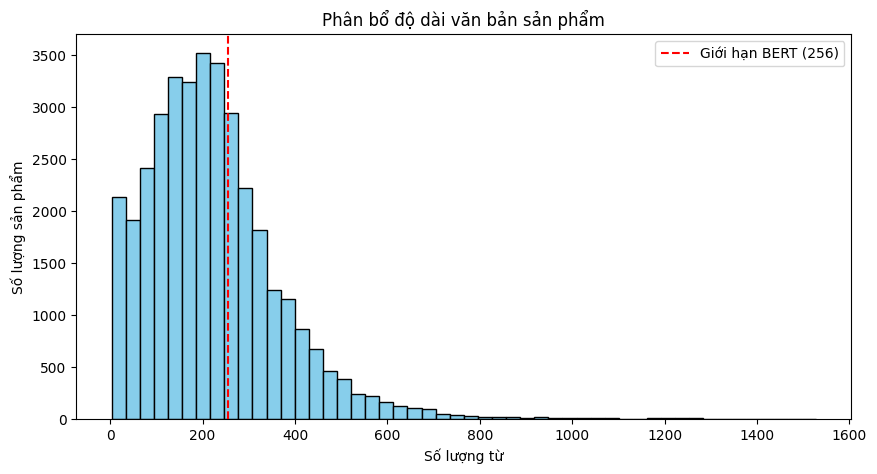

Độ dài trung bình: 223.17
Số sản phẩm dài hơn 256 từ: 12044


In [50]:
import matplotlib.pyplot as plt

# 1. Tính độ dài (số từ) của mỗi câu
doc_lengths = [len(s.split()) for s in df["sentences"]]

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.hist(doc_lengths, bins=50, color="skyblue", edgecolor="black")
plt.title("Phân bổ độ dài văn bản sản phẩm")
plt.xlabel("Số lượng từ")
plt.ylabel("Số lượng sản phẩm")
plt.axvline(x=256, color="red", linestyle="--", label="Giới hạn BERT (256)")
plt.legend()
plt.show()

# 3. Thống kê nhanh
print(f"Độ dài trung bình: {sum(doc_lengths)/len(doc_lengths):.2f}")
print(f"Số sản phẩm dài hơn 256 từ: {sum(1 for l in doc_lengths if l > 256)}")

In [51]:
from collections import Counter
import re

# Gộp tất cả thành một chuỗi khổng lồ, chuyển về chữ thường
all_text = " ".join(df["sentences"]).lower()
# Chỉ lấy các từ (loại bỏ dấu câu)
words = re.findall(r"\w+", all_text)

# Đếm tần suất
word_counts = Counter(words)
print("Top 20 từ phổ biến nhất:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

Top 20 từ phổ biến nhất:
and: 283927
the: 249592
baby: 202466
to: 186471
for: 160848
a: 124135
with: 109357
of: 92285
your: 92056
is: 80318
in: 78558
s: 59089
you: 57219
or: 52933
it: 50418
on: 44525
products: 43884
are: 42434
easy: 41973
can: 40877


In [52]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\thanh\AppData\Local\Temp\ipykernel_30016\3968219736.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Count", y="Text", data=df_ngram, palette="viridis")


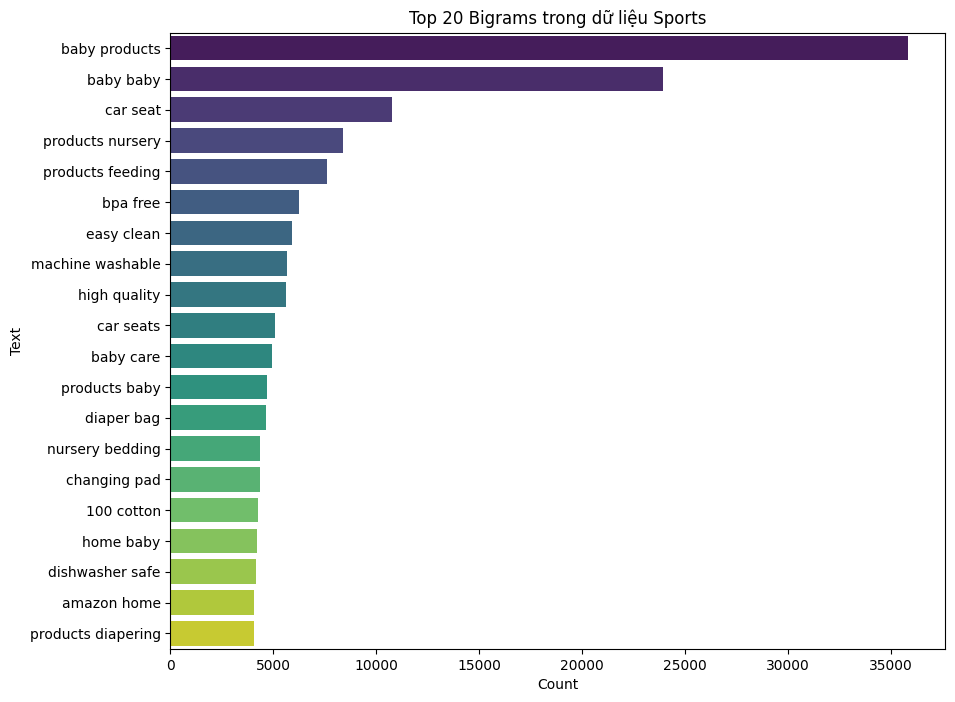

In [53]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt


def plot_top_ngrams(corpus, n=2, top_k=20):
    # Khởi tạo vectorizer để đếm cụm n-từ
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english").fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    # Lấy tần suất
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    # Vẽ biểu đồ
    df_ngram = pd.DataFrame(words_freq, columns=["Text", "Count"])
    plt.figure(figsize=(10, 8))
    sns.barplot(x="Count", y="Text", data=df_ngram, palette="viridis")
    plt.title(f"Top {top_k} Bigrams trong dữ liệu Sports")
    plt.show()


# Chạy thử với danh sách sentences của bạn
plot_top_ngrams(df["sentences"], n=2)

Giá trị nhỏ nhất: 3
Tứ phân vị Q1 (25%): 120.0
Trung vị (50%): 204.0
Tứ phân vị Q3 (75%): 292.0
Giá trị lớn nhất: 1528


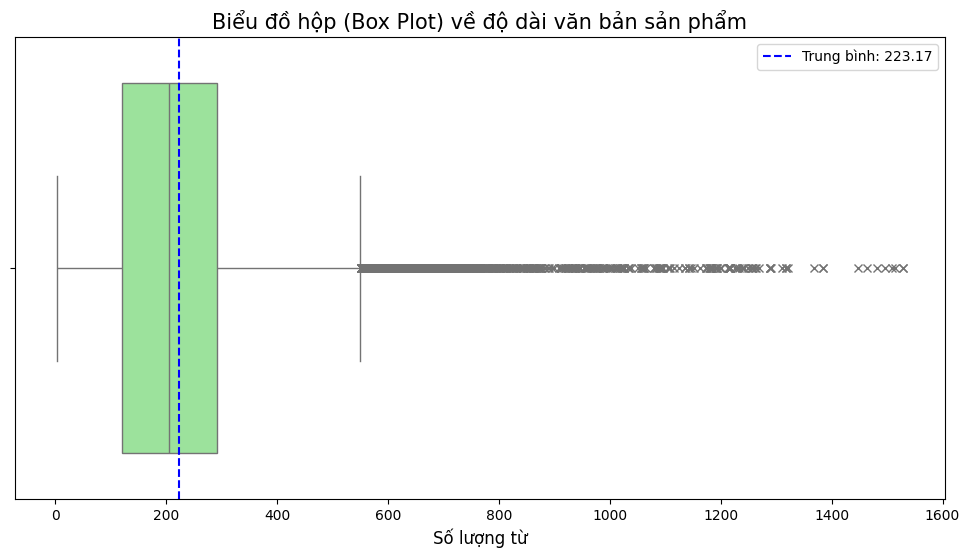

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán số lượng từ cho mỗi sản phẩm
doc_lengths = [len(s.split()) for s in df["sentences"]]

# 2. Khởi tạo khung hình
plt.figure(figsize=(12, 6))

# 3. Vẽ Box Plot nằm ngang
sns.boxplot(
    x=doc_lengths,
    color="lightgreen",
    flierprops={"marker": "x", "markerfacecolor": "red"},
)

# 4. Thêm các đường thông số quan trọng
mean_val = np.mean(doc_lengths)
plt.axvline(mean_val, color="blue", linestyle="--", label=f"Trung bình: {mean_val:.2f}")

# 5. Tinh chỉnh tiêu đề và nhãn
plt.title("Biểu đồ hộp (Box Plot) về độ dài văn bản sản phẩm", fontsize=15)
plt.xlabel("Số lượng từ", fontsize=12)
plt.legend()

# 6. Hiển thị các chỉ số thống kê cơ bản lên màn hình
quartiles = np.percentile(doc_lengths, [25, 50, 75])
print(f"Giá trị nhỏ nhất: {min(doc_lengths)}")
print(f"Tứ phân vị Q1 (25%): {quartiles[0]}")
print(f"Trung vị (50%): {quartiles[1]}")
print(f"Tứ phân vị Q3 (75%): {quartiles[2]}")
print(f"Giá trị lớn nhất: {max(doc_lengths)}")

plt.show()

In [ ]:
# %pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# list(set(df["price_tag"]))

['mid-range price', 'low price budget friendly', 'high price luxury premium']

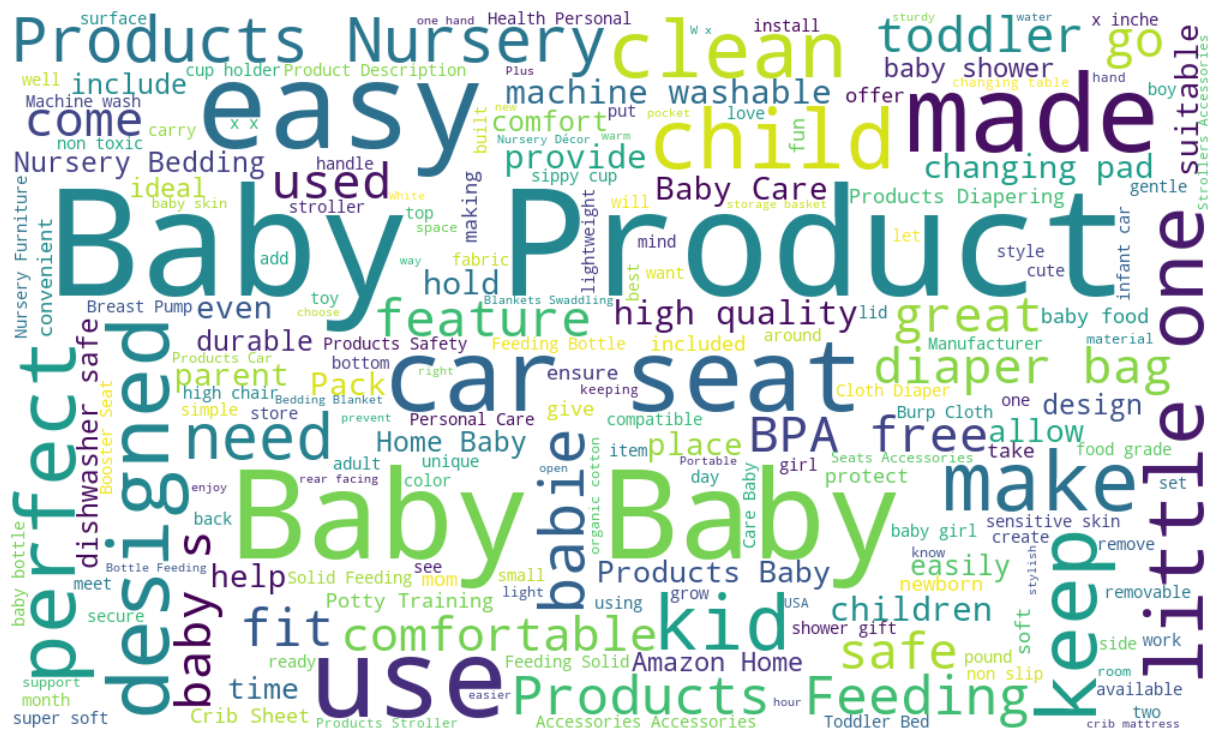

In [55]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. Gom tất cả các câu trong danh sách 'sentences' thành một chuỗi văn bản khổng lồ
text_data = " ".join(df["sentences"])

# 2. Thiết lập các từ muốn loại bỏ (Stopwords)
# Ngoài stopwords mặc định của tiếng Anh, bạn có thể thêm các từ xuất hiện quá nhiều nhưng vô nghĩa
my_stopwords = set(STOPWORDS)
my_stopwords.update(
    # ["baby", "item", "product", "will", "use"]
)  # Ví dụ nếu từ 'baby' quá to chiếm hết chỗ

# 3. Khởi tạo WordCloud
wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    stopwords=my_stopwords,
    max_words=200,  # Chỉ hiện 200 từ phổ biến nhất
    colormap="viridis",  # Màu sắc (có thể chọn: 'plasma', 'magma', 'inferno')
    min_font_size=10,
).generate(text_data)

# 4. Hiển thị bằng Matplotlib
plt.figure(figsize=(12, 8), facecolor=None)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Tắt trục tọa độ
plt.tight_layout(pad=0)

plt.show()

# (Tùy chọn) Lưu ảnh ra file
# wordcloud.to_file("my_wordcloud.png")

## Vẽ đồ thị code cũ sport chưa sửa cho baby

In [1]:
import torch
print(torch.__version__)

2.10.0+cpu


In [ ]:
# %pip install networkx

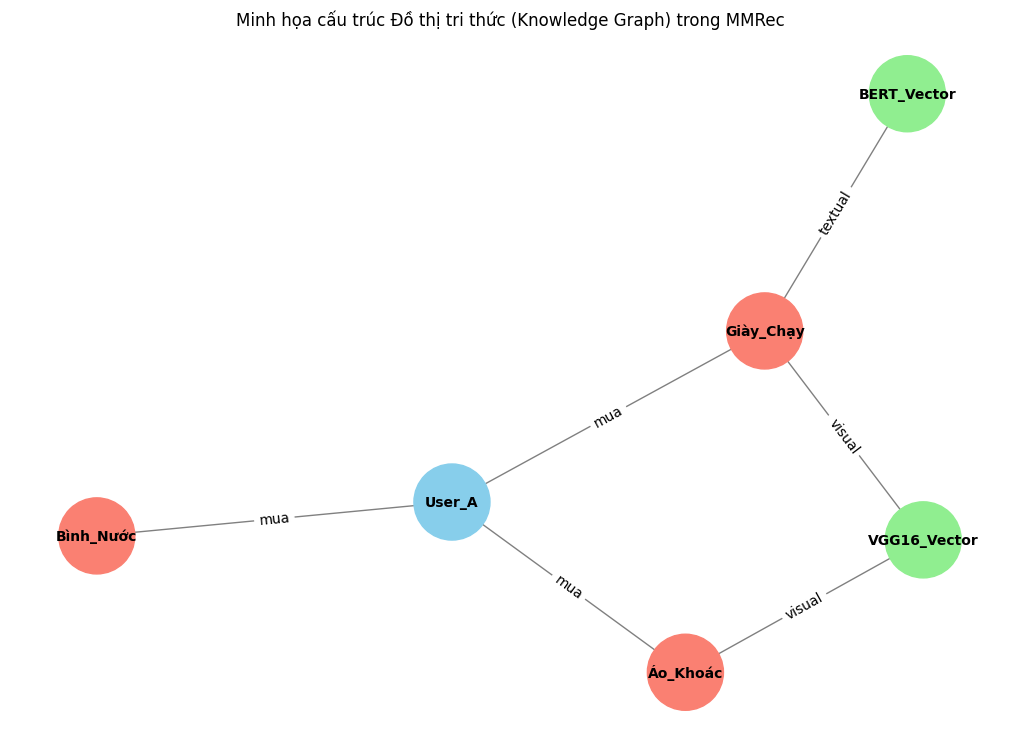

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Khởi tạo đồ thị
G = nx.Graph()

# 2. Thêm các Nút (Nodes) và phân loại nhóm để tô màu
user_node = "User_A"
items = ["Giày_Chạy", "Áo_Khoác", "Bình_Nước"]
features = ["VGG16_Vector", "BERT_Vector"]

G.add_node(user_node, type='user')
G.add_nodes_from(items, type='item')
G.add_nodes_from(features, type='feature')

# 3. Thêm các Cạnh (Edges) - Thiết lập mối quan hệ
# User mua sản phẩm
for item in items:
    G.add_edge(user_node, item, label='mua')

# Sản phẩm có đặc trưng đa phương thức
G.add_edge("Giày_Chạy", "VGG16_Vector", label='visual')
G.add_edge("Giày_Chạy", "BERT_Vector", label='textual')
G.add_edge("Áo_Khoác", "VGG16_Vector", label='visual')

# 4. Thiết lập vị trí và màu sắc để vẽ cho đẹp
pos = nx.spring_layout(G, seed=42) # Sắp xếp nút tự động

# Tô màu: User (Xanh dương), Item (Đỏ), Feature (Xanh lá)
color_map = []
for node in G:
    if G.nodes[node]['type'] == 'user':
        color_map.append('skyblue')
    elif G.nodes[node]['type'] == 'item':
        color_map.append('salmon')
    else:
        color_map.append('lightgreen')

# 5. Vẽ đồ thị
plt.figure(figsize=(10, 7))
nx.draw(G, pos, with_labels=True, node_color=color_map, 
        node_size=3000, font_size=10, font_weight='bold', edge_color='gray')

# Vẽ nhãn cho các cạnh (mua, visual, textual)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Minh họa cấu trúc Đồ thị tri thức (Knowledge Graph) trong MMRec")
plt.show()

In [ ]:
df_ratings.head(3)

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Lấy mẫu dữ liệu (Bạn nên lấy ít để hình không bị rối)
df_plot = df_ratings.head(30)

# 2. Khởi tạo đồ thị
G = nx.Graph()
for _, row in df_plot.iterrows():
    G.add_edge(row['userID'], row['itemID'])

# 3. Phân loại danh sách Node
user_nodes = [n for n in G.nodes if n in df_plot['userID'].unique()]
item_nodes = [n for n in G.nodes if n in df_plot['itemID'].unique()]

# 4. Thiết lập vị trí (Layout)
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.6, seed=42)

# 5. Vẽ từng nhóm Node với hình dáng và kích thước khác nhau
# Vẽ Người dùng (User): Hình tròn (o), kích thước nhỏ
nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, 
                       node_shape='o', 
                       node_size=200, 
                       node_color='white', 
                       edgecolors='black', 
                       label='Người dùng (User)')

# Vẽ Sản phẩm (Item): Hình vuông (s), kích thước lớn hơn
nx.draw_networkx_nodes(G, pos, nodelist=item_nodes, 
                       node_shape='s', 
                       node_size=500, 
                       node_color='lightgray', 
                       edgecolors='black', 
                       label='Sản phẩm (Item)')

# 6. Vẽ cạnh (Edges)
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.4, edge_color='black')

# 7. Thêm chú thích (Legend)
plt.legend(scatterpoints=1, loc='upper left', fontsize=12)

plt.title("Trực quan hóa Đồ thị tương tác đa thực thể", fontsize=15, pad=20)
plt.axis('off') # Tắt khung trục
plt.tight_layout()
plt.show()

In [ ]:
df_meta_with_reviews = pd.read_parquet(os.path.join(PATH, "meta_reviews_merged.gzip.parquet"), engine='pyarrow')

In [ ]:
df_meta_with_reviews[["reviewerID", "reviewerName"]]

In [ ]:
import pandas as pd

target_asin = "B000FON3KU"

# 1. Lấy thông tin sản phẩm (Bảng này chắc chắn có 'asin' và 'title')
df_target_item = df_meta_with_image[df_meta_with_image['asin'] == target_asin][['asin', 'title']]

# 2. Xử lý bảng Ratings (Tự động thích nghi với itemID hoặc asin)
col_item = 'itemID' if 'itemID' in df_ratings.columns else 'asin'
col_user = 'userID' if 'userID' in df_ratings.columns else 'reviewerID'

# Lọc dữ liệu rating
df_target_ratings = df_ratings[df_ratings[col_item] == target_asin].copy()

# 3. Lấy thông tin người dùng (Bảng này thường dùng reviewerID/reviewerName)
df_users = df_meta_with_reviews[['reviewerID', 'reviewerName']].drop_duplicates()

# 4. TIẾN HÀNH GHÉP BẢNG
# Ghép Ratings với Metadata
df_step1 = pd.merge(df_target_ratings, df_target_item, left_on=col_item, right_on='asin', how='inner')

# Ghép với thông tin tên người dùng
df_product_final_plot = pd.merge(df_step1, df_users, left_on=col_user, right_on='reviewerID', how='inner')

# 5. LÀM SẠCH VÀ CHUẨN BỊ VẼ
df_product_final_plot['reviewerName'] = df_product_final_plot['reviewerName'].fillna("User " + df_product_final_plot[col_user].str[:5])
df_product_final_plot = df_product_final_plot.head(5)

# Kiểm tra kết quả
print("Dữ liệu đã sẵn sàng để vẽ đồ thị:")
display(df_product_final_plot[['reviewerName', 'title', 'rating']])

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. Chuẩn bị dữ liệu (Giữ nguyên logic cũ)
target_item = df_ratings['itemID'].iloc[0]
df_sub = df_ratings[df_ratings['itemID'] == "B000FON3KU"].head(5)

# 2. Khởi tạo đồ thị
G = nx.Graph()
for _, row in df_sub.iterrows():
    u_id = row['userID'][:6] # Rút gọn ID
    i_id = row['itemID'][:6]
    rating_label = f"{int(row['rating'])}*"
    G.add_edge(u_id, i_id, label=rating_label)

user_nodes = [n for n in G.nodes if n != i_id]
item_node = [i_id]

# 3. Vẽ đồ thị
plt.figure(figsize=(12, 9))
# Sử dụng layout vòng tròn (shell) để các node vệ tinh bao quanh node trung tâm
pos = nx.shell_layout(G) 

# --- VẼ CÁC THÀNH PHẦN (Giữ nguyên viền đen, nền trắng/xám) ---
# Vẽ User (Hình tròn)
nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_shape='o', 
                       node_size=3000, node_color='white', edgecolors='black')

# Vẽ Item (Hình vuông)
nx.draw_networkx_nodes(G, pos, nodelist=item_node, node_shape='s', 
                       node_size=4500, node_color='#f5f6fa', edgecolors='black')

# Vẽ cạnh và nhãn ID lên Node
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Vẽ nhãn Rating (Sao) màu đỏ trên cạnh
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                              font_size=14, font_color='red', font_weight='bold')

# --- THÊM CHÚ THÍCH (TỐI GIẢN THEO YÊU CẦU) ---
# Tạo các đối tượng giả chỉ có hình dáng và nhãn để đưa vào Legend
user_handle = mlines.Line2D([], [], color='none', marker='o', 
                             markeredgecolor='black', markerfacecolor='white', 
                             markersize=12, label='Người dùng')

item_handle = mlines.Line2D([], [], color='none', marker='s', 
                             markeredgecolor='black', markerfacecolor='#f5f6fa', 
                             markersize=15, label='Sản phẩm')

# Hiển thị chú thích ở góc trên bên trái
plt.legend(handles=[user_handle, item_handle], loc='upper left', 
           title="Thực thể", fontsize=12, frameon=True)

plt.title(f"Mô hình hóa tương tác cục bộ (Sản phẩm: {i_id})", fontsize=15, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. Khởi tạo đồ thị từ DataFrame df_product_final_plot
G = nx.Graph()

# Lấy tên sản phẩm làm node trung tâm (rút gọn để không bị tràn node)
raw_title = df_product_final_plot['title'].iloc[0]
item_node_name = (raw_title[:25] + '...') if len(raw_title) > 25 else raw_title

# 2. Thêm các cạnh và node dựa trên dữ liệu thực tế
for _, row in df_product_final_plot.iterrows():
    u_name = row['reviewerName']
    r_label = f"{int(row['rating'])}*"
    
    # Tạo kết nối giữa người dùng và sản phẩm kèm nhãn rating
    G.add_edge(u_name, item_node_name, label=r_label)

# Tách danh sách node để định dạng hình dáng
user_nodes = [n for n in G.nodes if n != item_node_name]
item_node = [item_node_name]

# 3. Cấu hình vẽ đồ thị
plt.figure(figsize=(14, 10))
# Sử dụng spring_layout để các tên dài không bị đè lên nhau
pos = nx.spring_layout(G, k=1.5, seed=42) 

# --- VẼ CÁC THỰC THỂ ---
# Vẽ Người dùng: Hình tròn (o), nền trắng
nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_shape='o', 
                       node_size=5000, node_color='white', edgecolors='black')

# Vẽ Sản phẩm: Hình vuông (s), nền xám nhạt
nx.draw_networkx_nodes(G, pos, nodelist=item_node, node_shape='s', 
                       node_size=8000, node_color='#f5f6fa', edgecolors='black')

# Vẽ nhãn Text (Tên reviewer và Tiêu đề sản phẩm)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Vẽ đường nối (Cạnh)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')

# Vẽ nhãn Rating (Sao) màu đỏ nổi bật trên cạnh
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                              font_size=15, font_color='red', font_weight='bold')

# --- CHÚ THÍCH (LEGEND) ---
user_handle = mlines.Line2D([], [], color='none', marker='o', markeredgecolor='black', 
                             markerfacecolor='white', markersize=12, label='Người dùng (Reviewer)')
item_handle = mlines.Line2D([], [], color='none', marker='s', markeredgecolor='black', 
                             markerfacecolor='#f5f6fa', markersize=15, label='Sản phẩm (Title)')

plt.legend(handles=[user_handle, item_handle], loc='upper left', title="Thực thể", fontsize=11)

plt.title(f"Trực quan hóa Đồ thị tương tác thực tế\nSản phẩm: {raw_title[:50]}...", fontsize=15, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Tạo tập hợp những người dùng có reviewerName không phải là số và không rỗng
# Ta dùng .str.contains('[a-zA-Z]') để đảm bảo tên có ít nhất một chữ cái
df_valid_users = df_meta_with_reviews[
    df_meta_with_reviews['reviewerName'].str.contains('[a-zA-Z]', na=False)
].copy()

# 2. Tìm người dùng hợp lệ mà cũng có tồn tại trong bảng ratings
df_user_pool = pd.merge(
    df_ratings[['userID', 'itemID', 'rating']], 
    df_valid_users[['reviewerID', 'reviewerName']].drop_duplicates(),
    left_on='userID', right_on='reviewerID', how='inner'
)

# 3. Chọn người dùng đầu tiên từ danh sách "sạch" này
if not df_user_pool.empty:
    # Lấy người dùng có nhiều đánh giá một chút để đồ thị đẹp (tùy chọn)
    selected_user = df_user_pool.groupby('userID').size().sort_values(ascending=False).index[0]
    
    target_user_id = selected_user
    target_user_name = df_user_pool[df_user_pool['userID'] == target_user_id]['reviewerName'].iloc[0]
    
    # 4. Lọc đánh giá và lấy thông tin sản phẩm
    df_user_ratings = df_ratings[df_ratings['userID'] == target_user_id].copy()
    item_ids = df_user_ratings['itemID'].unique()
    df_items_info = df_meta_with_image[df_meta_with_image['asin'].isin(item_ids)][['asin', 'title']]

    # 5. Ghép bảng cuối cùng
    df_user_final_plot = pd.merge(df_user_ratings, df_items_info, left_on='itemID', right_on='asin', how='inner')
    df_user_final_plot['reviewerName'] = target_user_name
    
    # Lấy 5-6 sản phẩm để vẽ
    df_user_final_plot = df_user_final_plot.head(6)
    
    print(f"Đã lọc thành công người dùng: {target_user_name} ({target_user_id})")
    display(df_user_final_plot[['reviewerName', 'title', 'rating']])
else:
    print("Không tìm thấy người dùng nào có tên bằng chữ trong dữ liệu!")

In [ ]:
# Kiểm tra xem tên thật sự trong bảng gốc là gì
check_user = df_meta_with_reviews[df_meta_with_reviews['reviewerID'] == 'A3OXHLG6DIBRW8']
print(check_user[['reviewerID', 'reviewerName']])

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. Khởi tạo đồ thị
G = nx.Graph()

# Lấy tên người dùng làm node trung tâm
user_center_name = str(df_user_final_plot['reviewerName'].iloc[0])

# 2. Thêm các cạnh nối từ người dùng đến các sản phẩm họ đã đánh giá
for _, row in df_user_final_plot.iterrows():
    # Rút gọn tiêu đề sản phẩm cho gọn node
    raw_title = str(row['title'])
    item_label = (raw_title[:25] + '...') if len(raw_title) > 25 else raw_title
    rating_val = f"{int(row['rating'])}*"
    
    G.add_edge(user_center_name, item_label, label=rating_val)

# Tách danh sách node để định dạng
user_node = [user_center_name]
item_nodes = [n for n in G.nodes if n != user_center_name]

# 3. Vẽ đồ thị
plt.figure(figsize=(14, 10))
# Sử dụng shell_layout để tạo hình sao với User ở giữa
pos = nx.shell_layout(G) 

# Vẽ Người dùng trung tâm: Hình tròn (o), nền trắng
nx.draw_networkx_nodes(G, pos, nodelist=user_node, node_shape='o', 
                       node_size=6000, node_color='white', edgecolors='black')

# Vẽ các Sản phẩm vệ tinh: Hình vuông (s), nền xám nhạt
nx.draw_networkx_nodes(G, pos, nodelist=item_nodes, node_shape='s', 
                       node_size=4500, node_color='#f5f6fa', edgecolors='black')

# Vẽ nhãn Text (Tên người dùng và Tiêu đề sản phẩm)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Vẽ đường nối (Cạnh)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.4, edge_color='gray')

# Vẽ nhãn Rating màu đỏ trên cạnh
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                              font_size=14, font_color='red', font_weight='bold')

# --- CHÚ THÍCH (LEGEND) ---
user_h = mlines.Line2D([], [], color='none', marker='o', markeredgecolor='black', 
                        markerfacecolor='white', markersize=12, label='Người dùng trung tâm')
item_h = mlines.Line2D([], [], color='none', marker='s', markeredgecolor='black', 
                        markerfacecolor='#f5f6fa', markersize=15, label='Sản phẩm đã đánh giá')

plt.legend(handles=[user_h, item_h], loc='upper left', title="Thực thể", fontsize=11)

plt.title(f"Trực quan hóa Đồ thị sở thích người dùng\nNgười dùng: {user_center_name}", fontsize=15, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()